### **DATA ANALYSIS PYTHON PROJECT- BLINKIT ANALYSIS**

### **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **IMPORT RAW DATA**

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\project data analytics\project\Blinkit\blink python\Blinkit Grocery Data.csv")


In [3]:
df.head(20)      #sample data

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [4]:
df.tail(20)        #botton 20 data

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8503,Regular,FDR22,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.018473,NaN,109.9544,4.0
8504,Regular,FDS09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.080696,NaN,51.3008,4.0
8505,Regular,FDS34,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.076387,NaN,112.1518,4.0
8506,Regular,FDU09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.066275,NaN,54.1956,4.0
8507,Regular,FDU33,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.134057,NaN,45.3402,4.0
8508,Regular,FDU57,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.089121,NaN,149.8708,4.0
8509,Regular,FDU58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.028871,NaN,188.7898,4.0
8510,Regular,FDX46,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.057835,NaN,57.5562,4.0
8511,Regular,FDX57,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.047037,NaN,96.4068,4.0
8512,Regular,FDY33,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.096730,NaN,159.0262,4.0


In [5]:
print("size of Data: ",df.shape)     #row,column     #size of data

size of Data:  (8523, 12)


In [6]:
df.columns          #give about name of column info

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [7]:
df.dtypes        #different datatypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [8]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [9]:
 #now cleaning them by reg-Regular, LF-Low Fat,low fat-Low Fat
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF':'Low Fat',
                                                         'low fat': 'Low Fat',
                                                         'reg':'Regular'
                                                        })

                                                      

In [10]:
   print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


### **BUSINESS REQUIREMENTS**

### **KPI'S REQUIREMENT**

In [11]:
#TOTAL SALES
total_sales = df['Sales'].sum()

#AVERAGE SALES
avg_sales = df['Sales'].mean()

#NO. OF ITEMS SOLD
no_of_items_sold = df['Sales'].count()

#AVERAGE RATINGS
avg_ratings = df['Rating'].mean()

#display
print(f"Total Sales: ${total_sales:,.0f}")  #f=formatted space allows to  embed a string using curly braces
print(f"average Sales: ${avg_sales:,.0f}") 
print(f"no. of items sold: {no_of_items_sold:,.0f}") 
print(f"average ratings: {avg_ratings:,.1f}") 

Total Sales: $1,201,681
average Sales: $141
no. of items sold: 8,523
average ratings: 4.0


### **CHARTS REQUIREMENTS**

#### **TOTAL SALES BY FAT CONTENT**

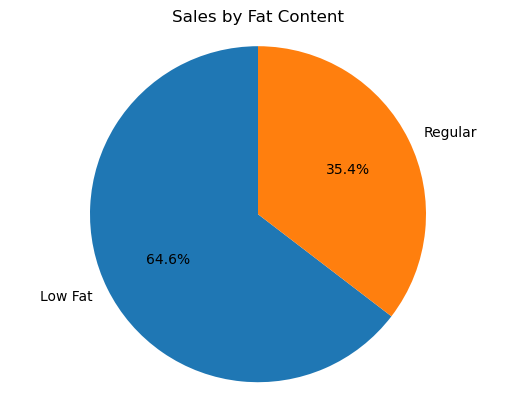

In [12]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index,
                        autopct = '%.1f%%' ,
                        startangle = 90)

plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

#### **TOTAL SALES BY ITEM TYPE**

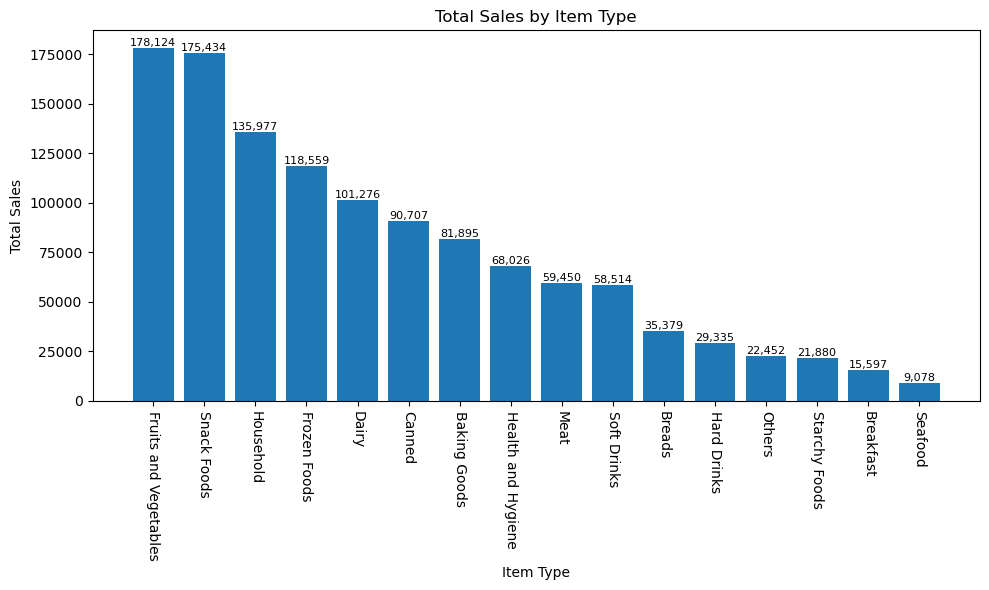

In [13]:
sales_by_type = df.groupby ('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=-90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')
           
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize= 8)
    
plt.tight_layout()
plt.show()

### **FAT CONTENT BY OUTLET FOR TOTAL SALES**

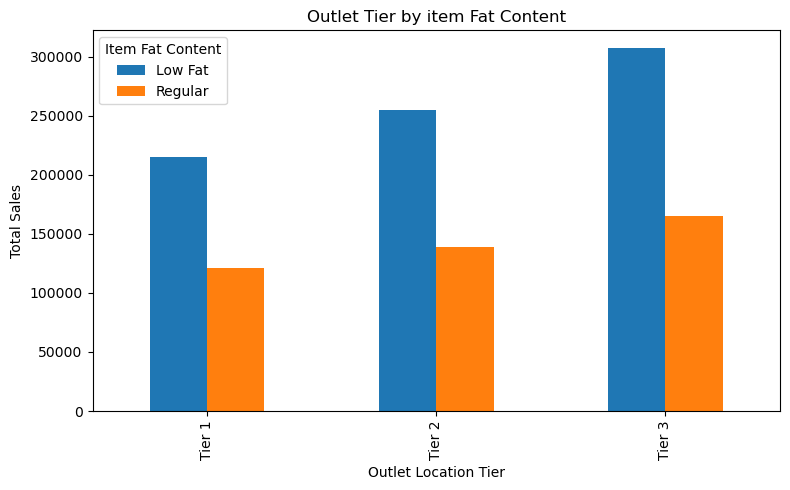

In [14]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
gouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet Tier by item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

### **TOTAL SALES BY OUTLET ESTABLISHMENT**

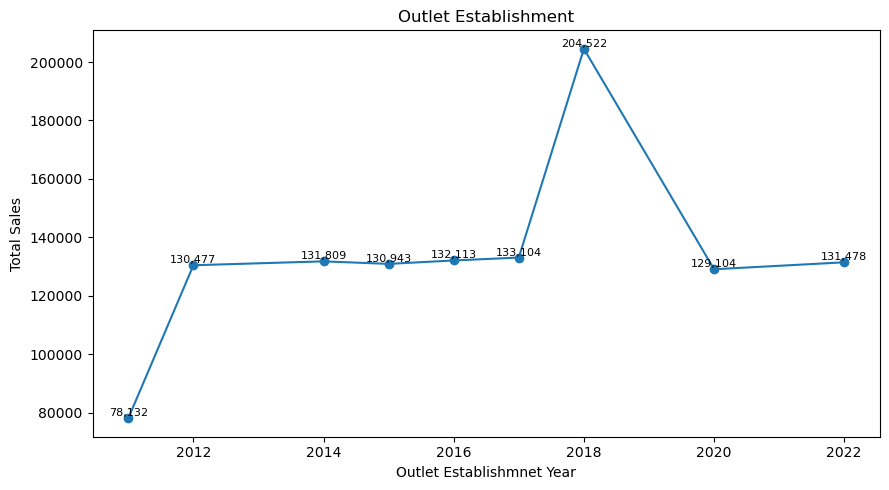

In [15]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishmnet Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}' ,ha= 'center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()